In [2]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [3]:
import os
os.environ['SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL'] = 'True'

# Install dl4ds after TensorFlow to ensure compatibility
!pip install dl4ds climetlab

# Uninstall standalone Keras 3 (it removes LocallyConnected2D)
!pip uninstall keras -y

# Install TensorFlow 2.15 with CUDA support (last version with Keras 2 bundled)
!pip install "tensorflow[and-cuda]==2.15.*"

INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 46.4 MB/s  0:00:00m0:00:010:02
   ━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/572.4 MB 53.7 MB/s eta 0:00:08^C
   ━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/572.4 MB 53.6 MB/s eta 0:00:08
ERROR: Operation cancelled by user
Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached keras-2.15.0-py3-none-any.whl (1.7 MB)


In [4]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import dl4ds as dds

# Reproducibility
np.random.seed(42)

2026-03-31 07:24:40.685474: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 07:24:40.732460: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-31 07:24:40.732478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-31 07:24:40.733476: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 07:24:40.740991: I tensorflow/core/platform/cpu_feature_guar

In [5]:
ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")
ds_truth = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

In [7]:
# =========================================
# Truth is the constraint — fit forecast to it
# =========================================
scale = 6

ds_truth    = ds_truth.sortby("latitude")     # ensure south → north
ds_forecast = ds_forecast.sortby("latitude")

tr_lons = ds_truth.longitude.values    # 90.0 → 140.0, 201 pts
tr_lats = ds_truth.latitude.values     # -15.0 → 30.0,  181 pts
fc_lats = ds_forecast.latitude.values  # -16.5 → 31.5
fc_lons = ds_forecast.longitude.values # 88.5  → 150.0

# ── Find forecast coords inside truth domain ──
valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]   # 90.0
lat_start = valid_lats[0]   # -15.0  ← south start, not 30.0

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))  # 0
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))  # 0

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx   # 201
avail_lat = len(tr_lats) - lat_start_idx   # 181

# ── Max forecast pts truth can support ──
max_fc_lon = avail_lon // scale   # 201 // 6 = 33
max_fc_lat = avail_lat // scale   # 181 // 6 = 30

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Crop forecast by index ──
fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude =slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat),
)
LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

# ── Slice truth by exact count ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + LOW_LON * scale),
    latitude =slice(lat_start_idx, lat_start_idx + LOW_LAT * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-3)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-3)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


In [8]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:      46848 | 0.02738%
10m_v_component_of_wind        | NaNs:      46848 | 0.02738%
2m_temperature                 | NaNs:      46848 | 0.02738%
total_precipitation_24hr       | NaNs:   11262720 | 6.58296%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [9]:
def count_nan_per_time(ds, var):
    data = ds[var]

    spatial_dims = [d for d in data.dims if d != "time"]

    nan_count = data.isnull().sum(dim=spatial_dims)

    result = nan_count.to_dataframe(name="nan_count")
    result = result[result["nan_count"] > 0]

    print(result.head(20))

    return result

nan_summary = count_nan_per_time(ds_fc, "10m_u_component_of_wind")

# Get worst timestep (most NaNs)
worst_time = nan_summary["nan_count"].idxmax()

print("Worst timestep:", worst_time)

            nan_count
time                 
2019-10-17      46848
Worst timestep: 2019-10-17 00:00:00


In [10]:
ds_fc = ds_fc.sel(prediction_timedelta=slice(np.timedelta64(1,'D'), None))

# Auto-detect and drop ALL fully-missing timesteps (not hardcoded)
all_missing = set()
for var in ds_fc.data_vars:
    data = ds_fc[var]
    spatial_dims = [d for d in data.dims if d != "time"]
    missing_mask = data.isnull().all(dim=spatial_dims)
    missing_times = ds_fc.time.where(missing_mask, drop=True).values
    all_missing.update(missing_times)

all_missing = sorted(all_missing)
print(f"Dropping {len(all_missing)} fully-missing timesteps: {all_missing}")

if len(all_missing) > 0:
    ds_fc = ds_fc.drop_sel(time=all_missing)
    ds_tr = ds_tr.drop_sel(time=all_missing)

Dropping 1 fully-missing timesteps: [numpy.datetime64('2019-10-17T00:00:00.000000000')]


In [9]:
check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [10]:
# ==============================
# CONFIG
# ==============================
lead_days = 1
lead_td = np.timedelta64(lead_days, "D")

# ==============================
# 1️⃣ Lead selection
# ==============================
ds_fc_lead = ds_fc.sel(prediction_timedelta=lead_td)

# ==============================
# 2️⃣ Compute valid time
# ==============================
valid_time = ds_fc_lead.time + lead_td

# ==============================
# 3️⃣ Find common times
# ==============================
common_times = np.intersect1d(valid_time.values,
                              ds_tr.time.values)

print("Common timesteps:", len(common_times))

# ==============================
# 4️⃣ Select only common times
# ==============================
ds_fc_lead = ds_fc_lead.assign_coords(valid_time=valid_time)
ds_fc_lead = ds_fc_lead.sel(valid_time=common_times)
ds_fc_lead = ds_fc_lead.assign_coords(time=ds_fc_lead.valid_time)
ds_fc_lead = ds_fc_lead.drop_vars("valid_time")

ds_tr_aligned = ds_tr.sel(time=common_times)

# ==============================
# 5️⃣ Final check
# ==============================
print("Forecast time == Truth time:",
      np.array_equal(ds_fc_lead.time.values,
                     ds_tr_aligned.time.values))

print("Forecast shape:",
      len(ds_fc_lead.time),
      len(ds_fc_lead.latitude),
      len(ds_fc_lead.longitude))

print("Truth shape:",
      len(ds_tr_aligned.time),
      len(ds_tr_aligned.latitude),
      len(ds_tr_aligned.longitude))

Common timesteps: 3648
Forecast time == Truth time: True
Forecast shape: 3648 24 32
Truth shape: 3648 144 192


In [11]:
ds_fc_lead

<xarray.Dataset> Size: 45MB
Dimensions:                   (time: 3648, longitude: 32, latitude: 24)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-02 ... 2022-...
  * longitude                 (longitude) float64 256B 90.0 91.5 ... 135.0 136.5
  * latitude                  (latitude) float64 192B -13.5 -12.0 ... 19.5 21.0
    prediction_timedelta      timedelta64[ns] 8B 1 days
Data variables:
    10m_u_component_of_wind   (time, longitude, latitude) float32 11MB -6.487...
    10m_v_component_of_wind   (time, longitude, latitude) float32 11MB 4.988 ...
    2m_temperature            (time, longitude, latitude) float32 11MB 299.4 ...
    total_precipitation_24hr  (time, longitude, latitude) float32 11MB 0.0012...

In [12]:
ds_tr_aligned

<xarray.Dataset> Size: 2GB
Dimensions:                   (time: 3648, latitude: 144, longitude: 192)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-02 ... 2022-...
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 403MB -6.10...
    10m_v_component_of_wind   (time, latitude, longitude) float32 403MB 5.379...
    2m_temperature            (time, latitude, longitude) float32 403MB 299.1...
    total_precipitation_24hr  (time, latitude, longitude) float32 403MB 0.000...

In [13]:
ds_tr_aligned[['total_precipitation_24hr']]

<xarray.Dataset> Size: 403MB
Dimensions:                   (time: 3648, latitude: 144, longitude: 192)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-02 ... 2022-...
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
Data variables:
    total_precipitation_24hr  (time, latitude, longitude) float32 403MB 0.000...

In [14]:
ds_fc_lead[['total_precipitation_24hr']]

<xarray.Dataset> Size: 11MB
Dimensions:                   (time: 3648, longitude: 32, latitude: 24)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-02 ... 2022-...
  * longitude                 (longitude) float64 256B 90.0 91.5 ... 135.0 136.5
  * latitude                  (latitude) float64 192B -13.5 -12.0 ... 19.5 21.0
    prediction_timedelta      timedelta64[ns] 8B 1 days
Data variables:
    total_precipitation_24hr  (time, longitude, latitude) float32 11MB 0.0012...

In [15]:
# ==============================
# Check variable scales (why normalization matters)
# ==============================
print("Variable statistics (showing why normalization is critical):\n")
print(f"{'Variable':<30} | {'Mean':>10} | {'Std':>10} | {'Min':>10} | {'Max':>10}")
print("=" * 80)

for var in ds_fc_lead.data_vars:
    data = ds_fc_lead[var].values
    data_clean = data[~np.isnan(data)]
    
    if len(data_clean) > 0:
        print(f"{var:<30} | {np.mean(data_clean):>10.4f} | {np.std(data_clean):>10.4f} | {np.min(data_clean):>10.4f} | {np.max(data_clean):>10.4f}")

print("\nNotice: Temperature (~290K) is 50x larger than winds (~5 m/s)")
print("Without normalization, temperature errors dominate the loss function!")

Variable statistics (showing why normalization is critical):

Variable                       |       Mean |        Std |        Min |        Max
10m_u_component_of_wind        |    -1.4688 |     4.1227 |   -28.7045 |    21.5950
10m_v_component_of_wind        |     0.4053 |     3.1723 |   -23.4216 |    24.4076
2m_temperature                 |   299.7216 |     2.1420 |   275.3997 |   308.0835
total_precipitation_24hr       |     0.0066 |     0.0087 |     0.0000 |     0.2689

Notice: Temperature (~290K) is 50x larger than winds (~5 m/s)
Without normalization, temperature errors dominate the loss function!


In [16]:
ARCH_PARAMS = dict(
    n_filters=36,          # Must be divisible by scale² (6²=36) for SPC upsampling
    n_blocks=8,
    normalization=None,    # Manual normalization below
    dropout_rate=0.0,
    dropout_variant='spatial',
    attention=False,
    activation='relu',
    localcon_layer=False   # Disabled - requires fixed spatial dimensions
)

# ==============================
# Per-variable training with MANUAL Z-SCORE NORMALIZATION
# DL4DS ResNet+SPC outputs 1 channel, so we train one model per variable
# ==============================

VAR_NAMES = list(ds_tr_aligned.data_vars)  # e.g. ['u10', 'v10', 't2m', 'tp']
trainers = {}
data = {}  # Initialize data dictionary to store test inputs/targets
norm_stats = {}  # Store normalization parameters (mean, std) for each variable

for i, var in enumerate(VAR_NAMES):
    print(f"\n{'='*60}")
    print(f"Training model for variable {i+1}/{len(VAR_NAMES)}: {var}")
    print(f"{'='*60}")

    # Extract single-channel data: (time, lat, lon, 1)
    target_var = ds_tr_aligned[[var]].to_array(dim='channel').transpose('time', 'latitude', 'longitude', 'channel')
    input_var  = ds_fc_lead[[var]].to_array(dim='channel').transpose('time', 'latitude', 'longitude', 'channel')

    n_samples  = len(target_var.time)
    train_size = int(0.70 * n_samples)
    val_size   = int(0.15 * n_samples)
    
    # ══════════════════════════════════════════════════════════════
    # MANUAL Z-SCORE NORMALIZATION (compute stats from training data only)
    # ══════════════════════════════════════════════════════════════
    train_data = target_var.isel(time=slice(0, train_size)).values
    mean_val = np.nanmean(train_data)
    std_val  = np.nanstd(train_data)
    
    # Avoid division by zero for constant fields
    if std_val < 1e-8:
        std_val = 1.0
    
    norm_stats[var] = {'mean': mean_val, 'std': std_val}
    print(f"  Normalization: mean={mean_val:.4f}, std={std_val:.4f}")
    
    # Normalize all data
    target_var_norm = (target_var - mean_val) / std_val
    input_var_norm  = (input_var - mean_val) / std_val

    data_var = {
        'train_target': target_var_norm.isel(time=slice(0, train_size)),
        'val_target'  : target_var_norm.isel(time=slice(train_size, train_size + val_size)),
        'test_target' : target_var_norm.isel(time=slice(train_size + val_size, None)),
        'train_input' : input_var_norm.isel(time=slice(0, train_size)),
        'val_input'   : input_var_norm.isel(time=slice(train_size, train_size + val_size)),
        'test_input'  : input_var_norm.isel(time=slice(train_size + val_size, None)),
    }

    trainer = dds.SupervisedTrainer(
        backbone='resnet',
        upsampling='spc',

        data_train=data_var['train_target'],
        data_val  =data_var['val_target'],
        data_test =data_var['test_target'],

        data_train_lr=data_var['train_input'],
        data_val_lr  =data_var['val_input'],
        data_test_lr =data_var['test_input'],

        scale=6,
        time_window=None,
        static_vars=None,

        predictors_train=None,
        predictors_val  =None,
        predictors_test =None,

        interpolation='inter_area',
        patch_size=None,
        batch_size=32,
        loss='mae',
        epochs=100,
        steps_per_epoch=None,
        validation_steps=None,
        test_steps=None,
        learning_rate=(1e-3, 1e-4),
        lr_decay_after=1e4,
        early_stopping=True,
        patience=6,
        min_delta=0,
        save=False,
        save_path=None,
        show_plot=True,
        verbose=True,
        device='GPU',
        **ARCH_PARAMS
    )

    trainer.run()
    trainers[var] = trainer
    
    # Store NORMALIZED test data (for model input)
    data[f'test_input_{var}']  = data_var['test_input']
    data[f'test_target_{var}'] = data_var['test_target']
    
    # Store ORIGINAL test data (for evaluation metrics in original units)
    data[f'test_input_orig_{var}']  = input_var.isel(time=slice(train_size + val_size, None))
    data[f'test_target_orig_{var}'] = target_var.isel(time=slice(train_size + val_size, None))

print("\n✅ All variables trained successfully!")
print("\n📊 Normalization stats:")
for var, stats in norm_stats.items():
    print(f"  {var:<30} | mean={stats['mean']:>10.4f} | std={stats['std']:>10.4f}")



Training model for variable 1/4: 10m_u_component_of_wind
  Normalization: mean=-1.2712, std=4.0403


2026-03-14 07:13:20.375675: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-14 07:13:20.436132: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-14 07:13:20.437348: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

List of devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of devices: 1
Global batch size: 32
--------------------------------------------------------------------------------
Starting time: 2026-03-14 07:13:20
--------------------------------------------------------------------------------
Model: "resnet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                Output Shape                                 Param #        Connected to                                 
 input_1 (InputLayer)                        [(None, None, None, 1)]                      0              []                                           
                                                                                                                                                      
 conv2d (Conv2D)                             (None, 

2026-03-14 07:13:25.296213: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-03-14 07:13:25.432748: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-14 07:13:25.661882: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-14 07:13:30.207491: I external/local_xla/xla/service/service.cc:168] XLA service 0x7530f509e5a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-14 07:13:30.207509: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2026-03-14 07:13:30.211894: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773472410.292803     305 device_co

79/79 [==============================] - 36s 174ms/step - loss: 0.3118 - val_loss: 0.2343
Epoch 2/100
79/79 [==============================] - 10s 129ms/step - loss: 0.2176 - val_loss: 0.2273
Epoch 3/100
79/79 [==============================] - 10s 130ms/step - loss: 0.2118 - val_loss: 0.2208
Epoch 4/100
79/79 [==============================] - 10s 131ms/step - loss: 0.2101 - val_loss: 0.2171
Epoch 5/100
79/79 [==============================] - 10s 132ms/step - loss: 0.2073 - val_loss: 0.2180
Epoch 6/100
79/79 [==============================] - 10s 133ms/step - loss: 0.2057 - val_loss: 0.2161
Epoch 7/100
79/79 [==============================] - 10s 133ms/step - loss: 0.2039 - val_loss: 0.2122
Epoch 8/100
79/79 [==============================] - 11s 134ms/step - loss: 0.2003 - val_loss: 0.2105
Epoch 9/100
79/79 [==============================] - 11s 134ms/step - loss: 0.1996 - val_loss: 0.2090
Epoch 10/100
79/79 [==============================] - 11s 134ms/step - loss: 0.1971 - val_loss

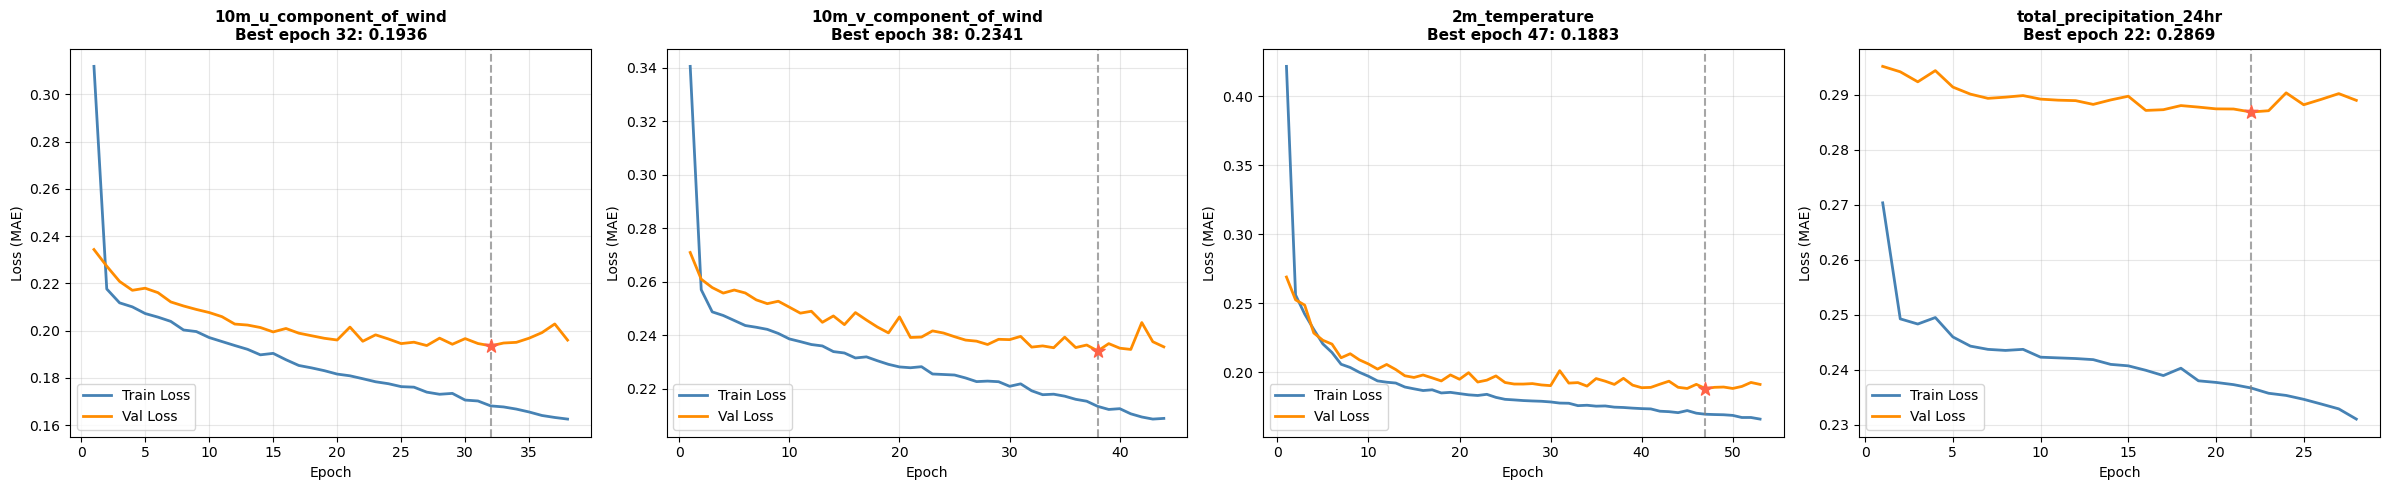

In [17]:
# ==============================
# PLOT TRAINING HISTORY (all variables)
# ==============================

VAR_LABELS_VIZ = list(ds_fc_lead.data_vars)
fig, axes = plt.subplots(1, len(VAR_LABELS_VIZ), figsize=(6 * len(VAR_LABELS_VIZ), 5))

if len(VAR_LABELS_VIZ) == 1:
    axes = [axes]

for ax, var in zip(axes, VAR_LABELS_VIZ):
    history = trainers[var].fithist.history
    epochs_range = range(1, len(history["loss"]) + 1)
    ax.plot(epochs_range, history["loss"],     label="Train Loss",  linewidth=2, color="steelblue")
    ax.plot(epochs_range, history["val_loss"], label="Val Loss",    linewidth=2, color="darkorange")
    best_epoch = np.argmin(history["val_loss"]) + 1
    best_loss  = min(history["val_loss"])
    ax.axvline(best_epoch, color="gray", linestyle="--", alpha=0.7)
    ax.scatter([best_epoch], [best_loss], color="tomato", zorder=5, s=100, marker="*")
    ax.set_title(f"{var}\nBest epoch {best_epoch}: {best_loss:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MAE)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dl4ds_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
# ==============================
# EVALUATE MODEL ON TEST SAMPLE (per variable)
# ==============================

VAR_LABELS_VIZ = list(ds_fc_lead.data_vars)
target_date = np.datetime64("2022-08-01")

FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]


test_times = ds_tr_aligned.time.values[int(0.85 * len(ds_tr_aligned.time)):]
idx = np.where(test_times == target_date)[0]

if len(idx) == 0:
    print(f"⚠️  {target_date} not found in test set.")
    print(f"Available range: {test_times[0]} → {test_times[-1]}")
    print(f"Using first test sample instead: {test_times[0]}")
    idx = 0
    target_date = test_times[0]
else:
    idx = idx[0]

print(f"Using date: {target_date}")
print(f"Test index: {idx}")

import tensorflow as tf

predictions = {}
for var in VAR_LABELS_VIZ:
    model = trainers[var].model
    
    # Use NORMALIZED data for model input
    X = data[f'test_input_{var}'].isel(time=idx).values       # (24, 32, 1) - normalized
    X_batch = np.expand_dims(X, axis=0)                        # (1, 24, 32, 1)
    Y_pred_norm  = model.predict(X_batch, verbose=0)[0]        # (144, 192, 1) - normalized
    
    # DENORMALIZE predictions back to original units
    mean_val = norm_stats[var]['mean']
    std_val  = norm_stats[var]['std']
    Y_pred = Y_pred_norm * std_val + mean_val                  # (144, 192, 1) - original units
    
    # Use ORIGINAL data for input and truth (for visualization)
    X_orig = data[f'test_input_orig_{var}'].isel(time=idx).values   # (24, 32, 1)
    Y_orig = data[f'test_target_orig_{var}'].isel(time=idx).values  # (144, 192, 1)
    
    predictions[var] = {
        'input': X_orig[:, :, 0],
        'pred' : Y_pred[:, :, 0],
        'truth': Y_orig[:, :, 0],
    }

print("\nPrediction shapes:")
for var, d in predictions.items():
    print(f"  {var}: input={d['input'].shape}, pred={d['pred'].shape}, truth={d['truth'].shape}")


Using date: 2022-08-01
Test index: 242

Prediction shapes:
  10m_u_component_of_wind: input=(24, 32), pred=(144, 192), truth=(144, 192)
  10m_v_component_of_wind: input=(24, 32), pred=(144, 192), truth=(144, 192)
  2m_temperature: input=(24, 32), pred=(144, 192), truth=(144, 192)
  total_precipitation_24hr: input=(24, 32), pred=(144, 192), truth=(144, 192)


/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/conda/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


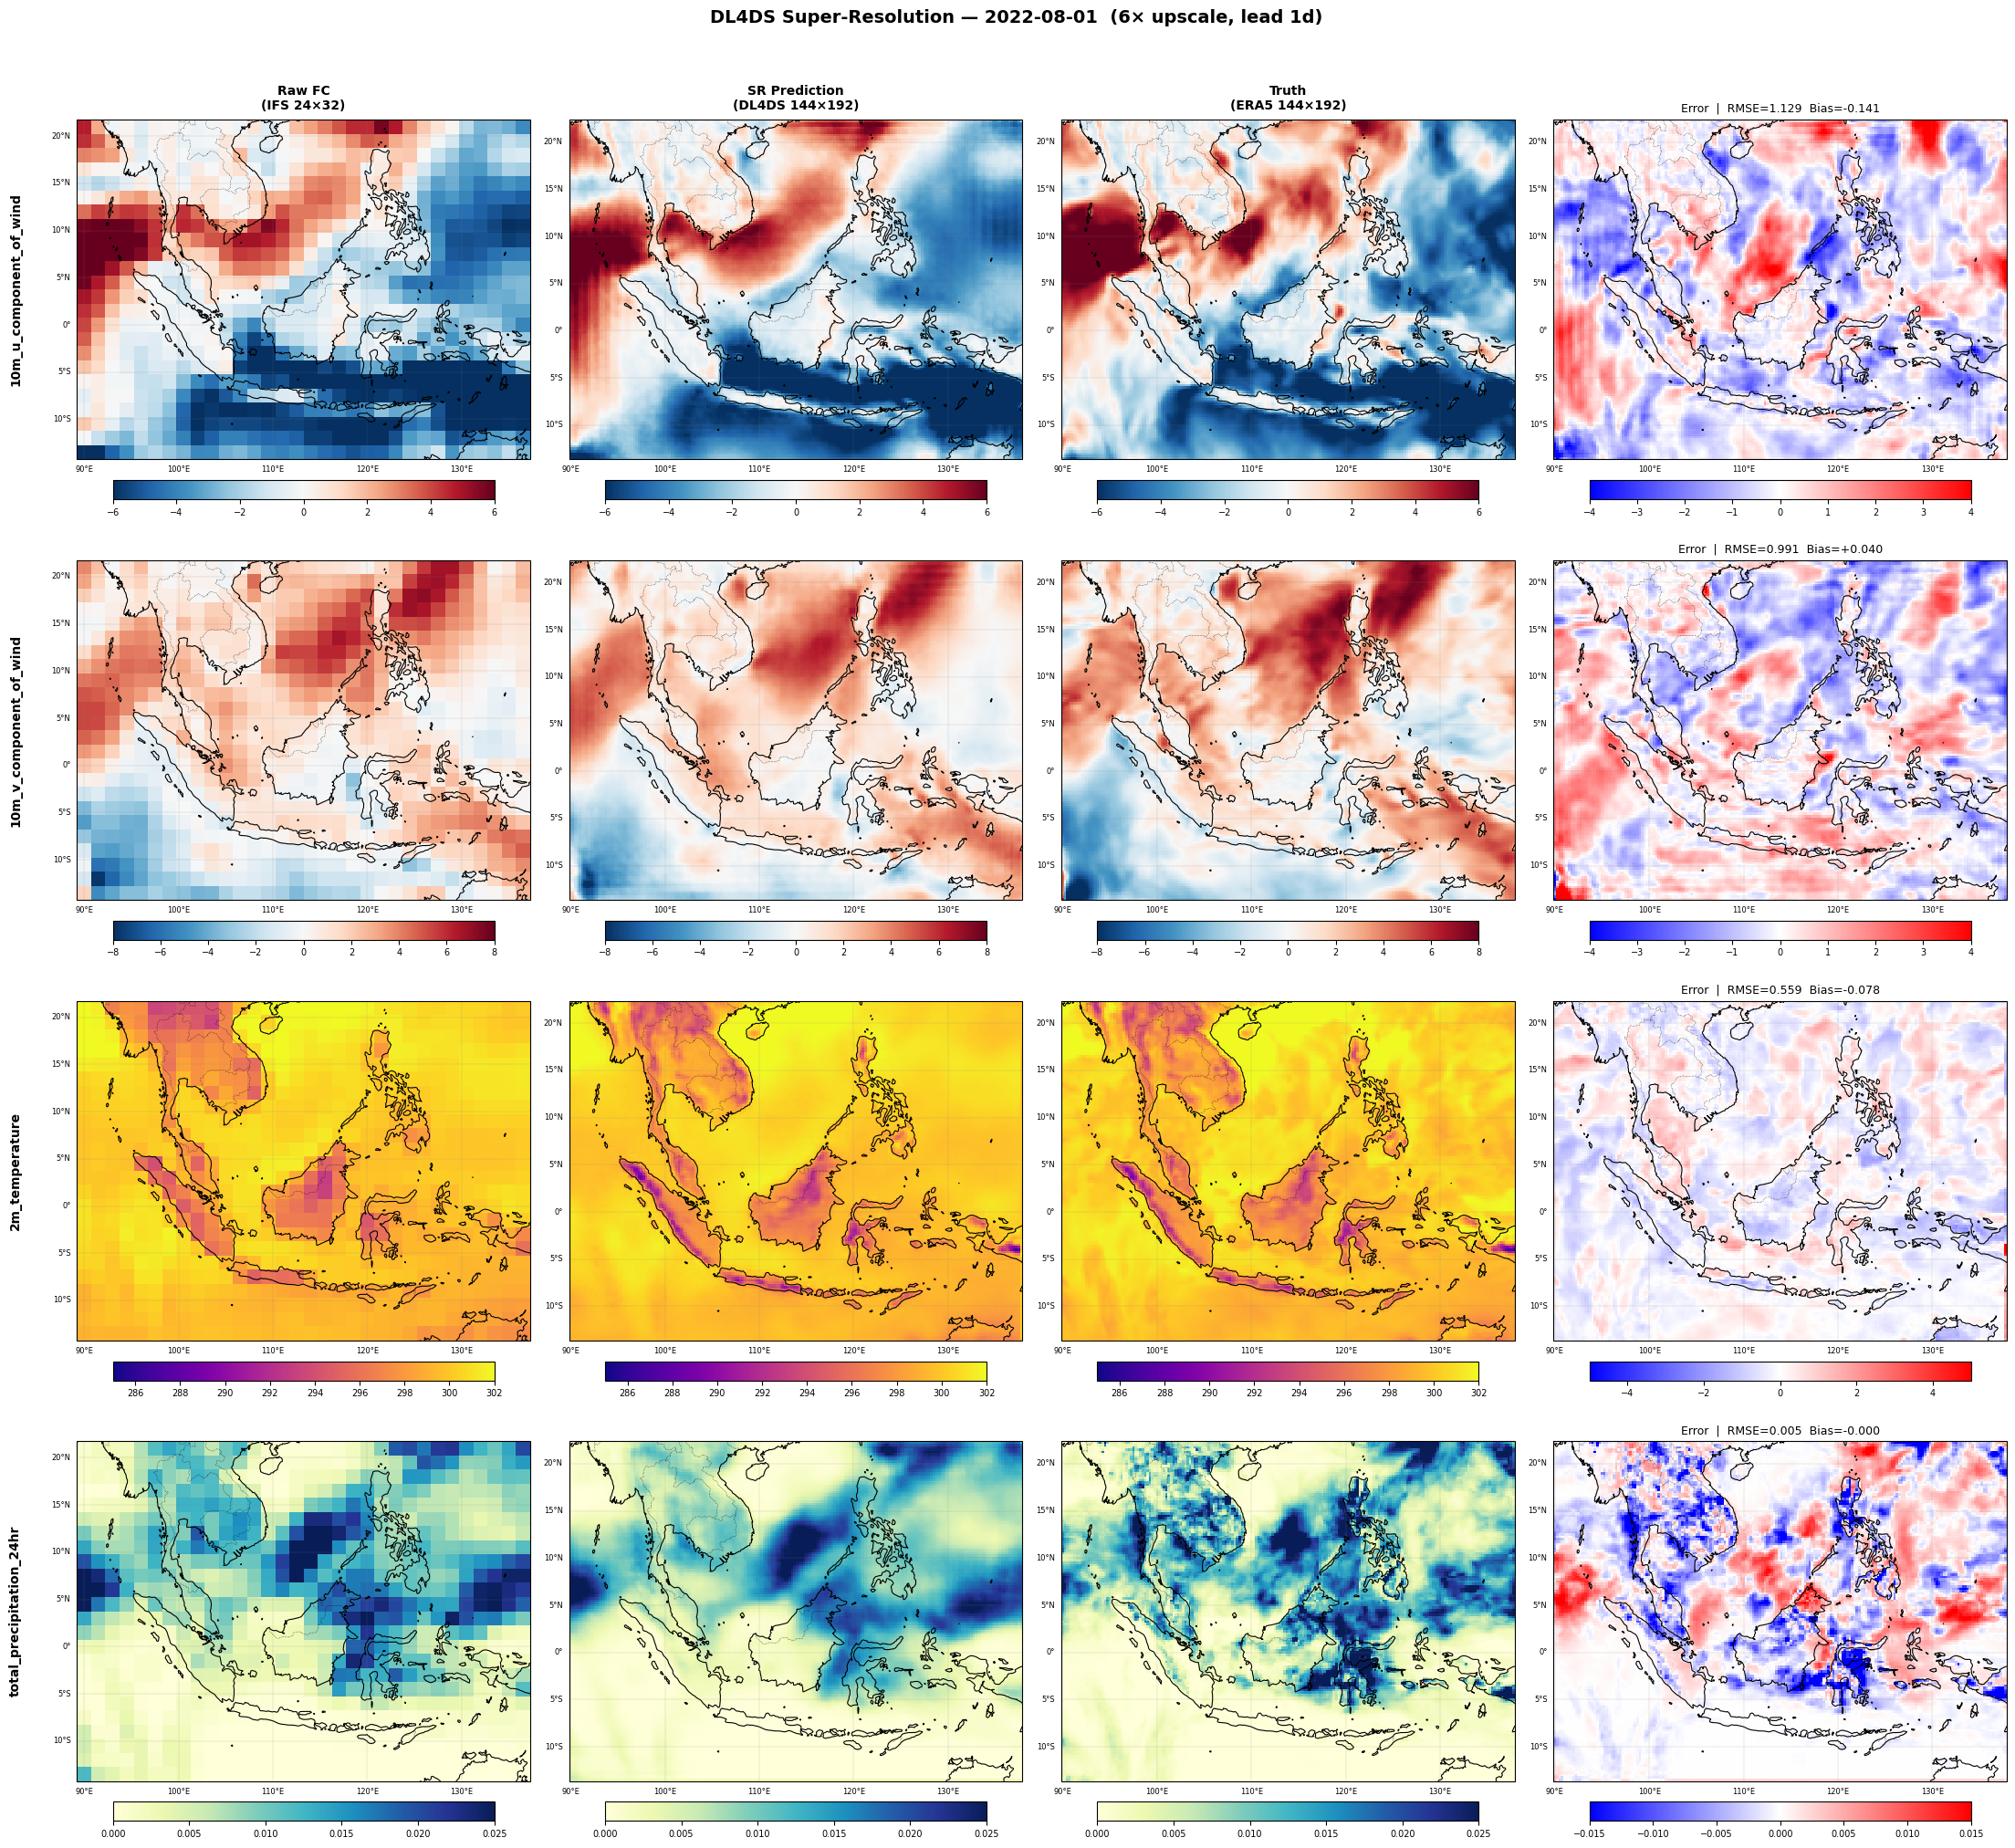


EVALUATION METRICS FOR 2022-08-01
10m_u_component_of_wind        | RMSE:   1.1291 | Bias:  -0.1408 | MAE:   0.8415
10m_v_component_of_wind        | RMSE:   0.9906 | Bias:  +0.0404 | MAE:   0.7566
2m_temperature                 | RMSE:   0.5588 | Bias:  -0.0784 | MAE:   0.4288
total_precipitation_24hr       | RMSE:   0.0054 | Bias:  -0.0005 | MAE:   0.0030


In [19]:
# ==============================
# VISUALIZE PREDICTIONS (per variable)
# ==============================

proj = ccrs.PlateCarree()
n_vars = len(VAR_LABELS_VIZ)

col_titles = [
    "Raw FC\n(IFS 24×32)",
    "SR Prediction\n(DL4DS 144×192)",
    "Truth\n(ERA5 144×192)",
    "Error\n(Pred - Truth)",
]

cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

lons_lr = ds_fc_lead.longitude.values
lats_lr = ds_fc_lead.latitude.values
lons_hr = ds_tr_aligned.longitude.values
lats_hr = ds_tr_aligned.latitude.values

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v, var_name in enumerate(VAR_LABELS_VIZ):
    raw_v  = predictions[var_name]['input']   # (24, 32)
    pred_v = predictions[var_name]['pred']    # (144, 192)
    true_v = predictions[var_name]['truth']   # (144, 192)
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v]
    vmin, vmax, elim = FIELD_VMIN[v], FIELD_VMAX[v], ERROR_LIM[v]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, err_v,  "bwr",  -elim,  elim),
    ]

    for col, (lons, lats, field, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]
        im = ax.pcolormesh(lons, lats, field, cmap=cmap, vmin=lo, vmax=hi,
                           shading="nearest", transform=proj)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}
        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)
        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, var_name, transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", rotation=90)

    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}", fontsize=9, pad=6)

fig.suptitle(
    f"DL4DS Super-Resolution — {str(target_date)[:10]}  (6× upscale, lead 1d)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(f"dl4ds_eval_{str(target_date)[:10]}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*60}")
print(f"EVALUATION METRICS FOR {str(target_date)[:10]}")
print(f"{'='*60}")
for v, var_name in enumerate(VAR_LABELS_VIZ):
    pred_v = predictions[var_name]['pred']
    true_v = predictions[var_name]['truth']
    err_v  = pred_v - true_v
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    mae  = np.mean(np.abs(err_v))
    print(f"{var_name:30s} | RMSE: {rmse:8.4f} | Bias: {bias:+8.4f} | MAE: {mae:8.4f}")
print(f"{'='*60}")


In [20]:
# ==============================
# Aggregate test-set evaluation
# ==============================
from scipy.stats import pearsonr

VAR_LABELS_VIZ = list(ds_fc_lead.data_vars)

print("\n" + "=" * 100)
print(f"{'Variable':<24} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("=" * 100)

for var in VAR_LABELS_VIZ:
    model   = trainers[var].model
    n_test  = len(data[f'test_target_{var}'].time)
    
    # Get normalization stats for denormalization
    mean_val = norm_stats[var]['mean']
    std_val  = norm_stats[var]['std']

    pred_list, true_list, base_list = [], [], []

    for i in range(n_test):
        # NORMALIZED low-res input: (24, 32, 1)
        X_norm = data[f'test_input_{var}'].isel(time=i).values
        
        # ORIGINAL data for truth and baseline
        X_orig = data[f'test_input_orig_{var}'].isel(time=i).values
        Y_orig = data[f'test_target_orig_{var}'].isel(time=i).values  # (144, 192, 1)

        # Model prediction (normalized) → denormalize to original units
        X_batch = np.expand_dims(X_norm, axis=0)                      # (1, 24, 32, 1)
        Y_pred_norm = model.predict(X_batch, verbose=0)[0]            # (144, 192, 1) - normalized
        Y_pred = Y_pred_norm * std_val + mean_val                     # Denormalize to original units

        # Bilinear baseline: upsample ORIGINAL low-res to high-res
        import tensorflow as tf
        X_4d   = tf.constant(np.expand_dims(X_orig, axis=0))         # (1, 24, 32, 1)
        X_up   = tf.image.resize(X_4d, [144, 192], method='bilinear')[0].numpy()  # (144, 192, 1)

        pred_list.append(Y_pred[:, :, 0])
        true_list.append(Y_orig[:, :, 0])
        base_list.append(X_up[:, :, 0])

    pred_v = np.concatenate(pred_list)
    true_v = np.concatenate(true_list)
    base_v = np.concatenate(base_list)

    # Remove NaN pairs
    mask = ~(np.isnan(pred_v) | np.isnan(true_v) | np.isnan(base_v))
    pred_v, true_v, base_v = pred_v[mask], true_v[mask], base_v[mask]

    # Model metrics
    rmse      = np.sqrt(np.mean((pred_v - true_v) ** 2))
    mae       = np.mean(np.abs(pred_v - true_v))
    bias      = np.mean(pred_v - true_v)
    corr      = pearsonr(pred_v, true_v)[0]

    # Bilinear baseline RMSE
    rmse_base = np.sqrt(np.mean((base_v - true_v) ** 2))

    # Skill score: 1 - (RMSE_model / RMSE_baseline)
    skill     = 1.0 - (rmse / rmse_base) if rmse_base > 0 else 0.0

    print(f"{var:<24} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("=" * 100)
print("\nSkill > 0 means DL4DS improves over bilinear interpolation baseline.")



Variable                 |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
10m_u_component_of_wind  |   1.1240 |   0.8255 |  -0.0802 |   0.9574 |         1.5320 |  +0.2663
10m_v_component_of_wind  |   1.0856 |   0.8013 |  +0.0473 |   0.9384 |         1.3577 |  +0.2005
2m_temperature           |   0.6155 |   0.4532 |  -0.1102 |   0.9549 |         1.2546 |  +0.5094
total_precipitation_24hr |   0.0068 |   0.0032 |  -0.0007 |   0.8086 |         0.0074 |  +0.0878

Skill > 0 means DL4DS improves over bilinear interpolation baseline.
